# Assignment 4 $-$ Argument Assessment
_Solutions have to be submitted in pairs of two by Monday, June 22nd, 23:59 (UTC+2)._

**Grading:**

This assignment is worth 30 points, which you earn through running code without unhandled, preventable errors, correct outputs, and answers to analysis questions
- **0 - *Fail*:** No submission; non-working code (preventable errors and exceptions); code that directly contradicts the task description or produces incorrect outputs; authorship violations like plagiarism or solutions fully or largely generated by AI

**Submission Components:**

- **Code:** Tasks 1 and 2
  - **Output Files:** Your submission should include the output files in the correct folder with the correct naming.
  - **Explanation:** You should add overall explanations of your code (i.e., modify/employ docstrings) and comments for individual implementation decisions.
- **Analysis:** Task 3 answered in full text with sensible formatting and using the results from task 2 explicitly.

**Submission Group:**
YOUR ANSWER HERE

In [ ]:
# As you train a neural model, you need access to a GPU:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU is available:", torch.cuda.is_available())

## Introduction

### Learning Goals
- Train a multitask neural model
- Compare different models' performance

### Topics Covered
- Multitask and transfer learning
- Huggingface library
- Dimensions of argument quality
  
### Motivation: What makes a good argument?

Consider the following two arguments for the same claim:

<table>
  <thead>
    <tr>
      <th markdown>
Social media brings more harm than good.
      </th>
      <th markdown>
      </th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td markdown>
64% of people who use Twitter for news say they have encountered something they later discovered wasn't true.
      </td>
      <td markdown>
A study published in the journal Science found that lies spread six times faster than the truth on Twitter, and 'fake news' is retweeted more often than true news.
      </td>
    </tr>
  </tbody>
</table>


To decide if either argument is 'good', argument strength can be defined using many features, and from different angles. This makes argument assessment a very complex and inherently subjective task.

**Dimensions of argument strength:**

- Logic: evidence quality, acceptable/relevant premise, etc.
- Dialectic: acceptability, reasonableness, etc.
- Rhetoric: persuasiveness, emotional appeal, credibility, etc.
  - Surface features like grammar/typos or linguistic clarity also influence rhetorical strength
  - While all dimensions of argument strength are subjective, persuasiveness is especially influenced by aspects like prior stance, values, biases, etc
  
**Definitions from different directions:**

- Conceptual notions: minimal (appropriate, acceptable) vs. maximal (constructive, productive) quality
- Influence Factors: context (discussion, demographics) vs. argument (style, content)
- Computational Models: improvement (feedback, generation) vs. assessment vs. retrieval (ranking)

### General Description

Given data annotated for _overall argument quality_ and three different quality aspects (_cogency, effectiveness, reasonableness_), train different single- and multitask models for AQ Assessment and compare model performances.

- **Baseline** How does the pretrained model perform without finetuning?
- **Single-task** How does a model perform that is finetuned to classify _overall AQ_?
- **Transfer** How does a model perform that is finetuned to classify one quality aspect on overall argument quality?
- **Continual Multitask** How does a model perform in _overall AQ_ classification that is trained first on one AQ aspect and then partly on _overall AQ_?

### Multitask and Transfer Learning
(Non-LLM) Machine Learning generally trains one model for one task, ignoring knowledge from training signals of _related tasks_


- **Goal:** find useful information across multiple related tasks to improve generalization, data efficiency, training speed, and reduce overfitting
- **Joint Learning:** share (some/all) hidden layers, while keeping task-specific output layers, and train all objectives simultaneously
  
  $\to$ both tasks profit from shared information (e.g., shared encoders in seq2seq Machine Translation setups)
- **Continual/Transfer Learning:** train a model on an auxiliary task, then train on the primary task (sometimes while freezing hidden layers) 
  
  $\to$ resource-sparse task profits from related pre-training

### Example Architectures

**General Transformer Architecture:** Encoder (orange) and decoder (yellow) transformers with a prediction head using a linear layer (blue/green)

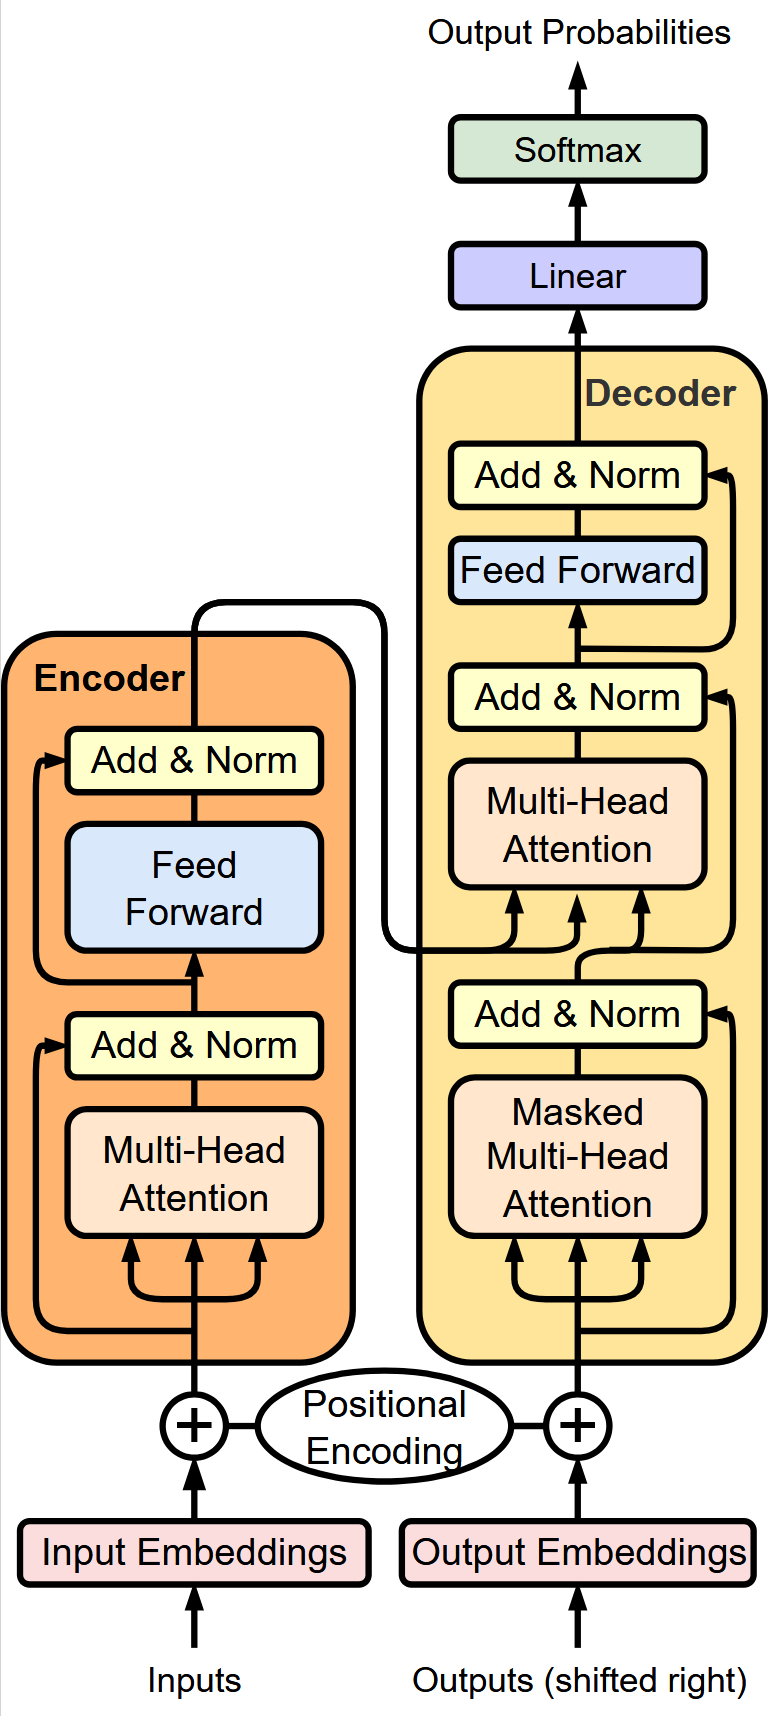

**Joint Multitask Learning:** Neural network with shared hidden layers, either in the encoder or the full hidden model, with task-specific prediction heads. During training, the different tasks are trained alternately.

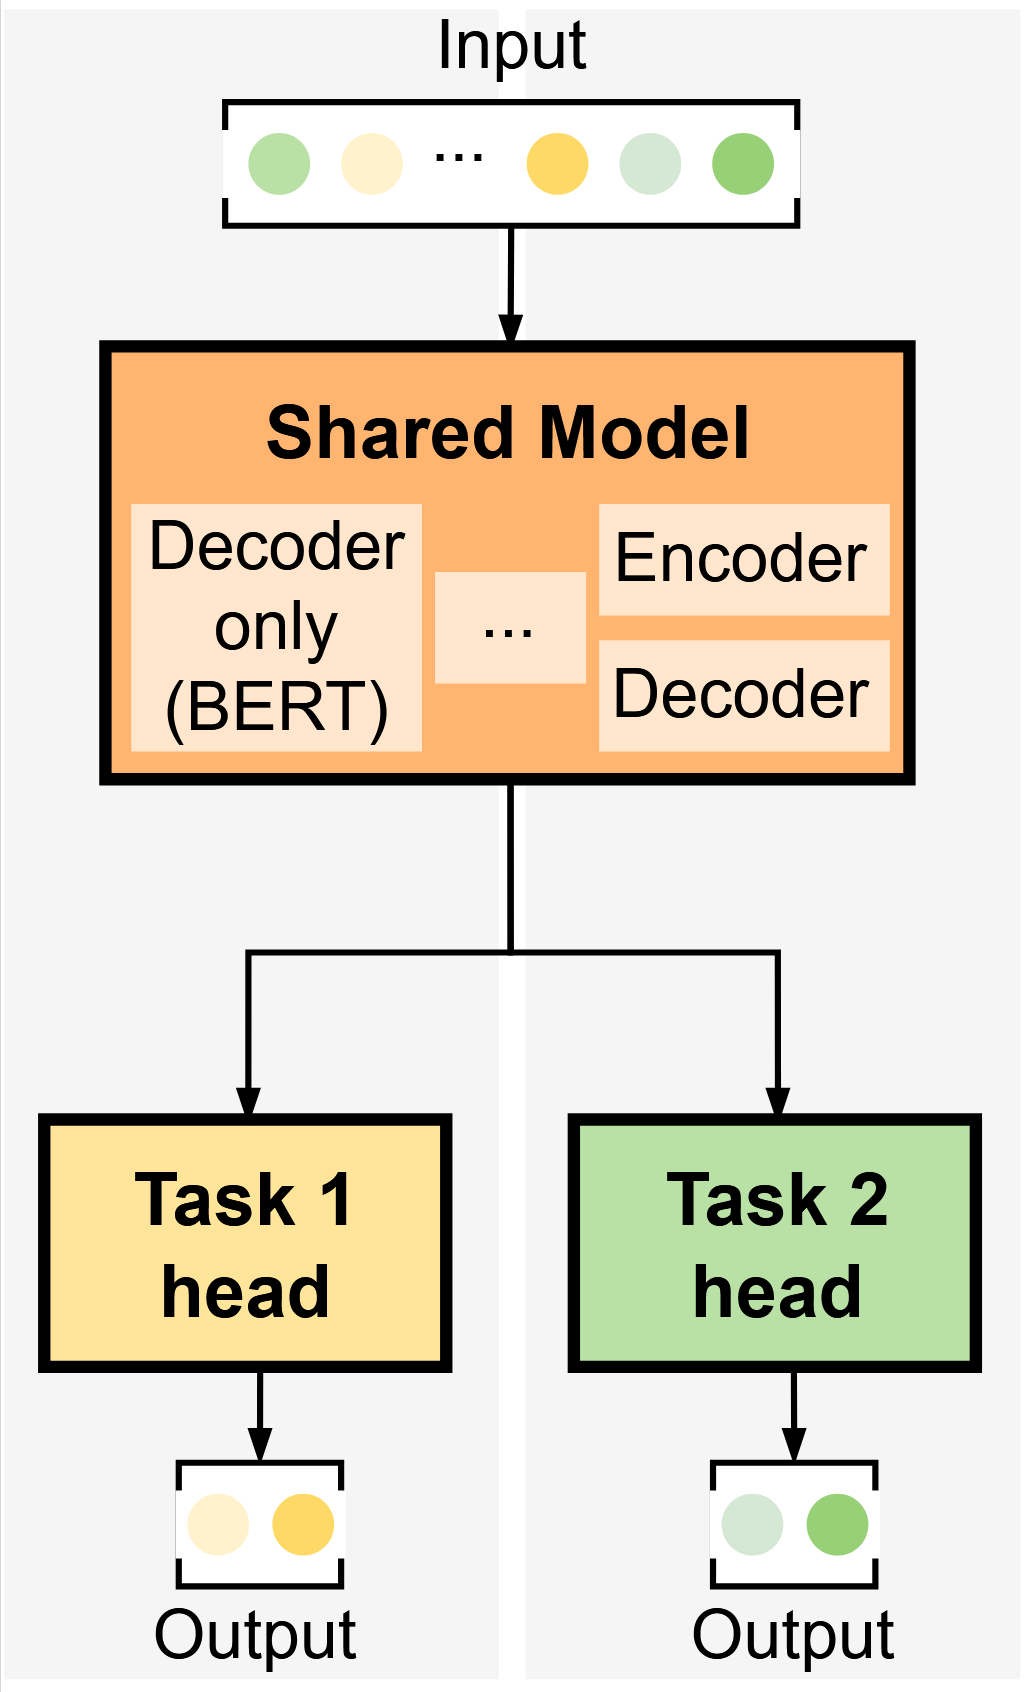
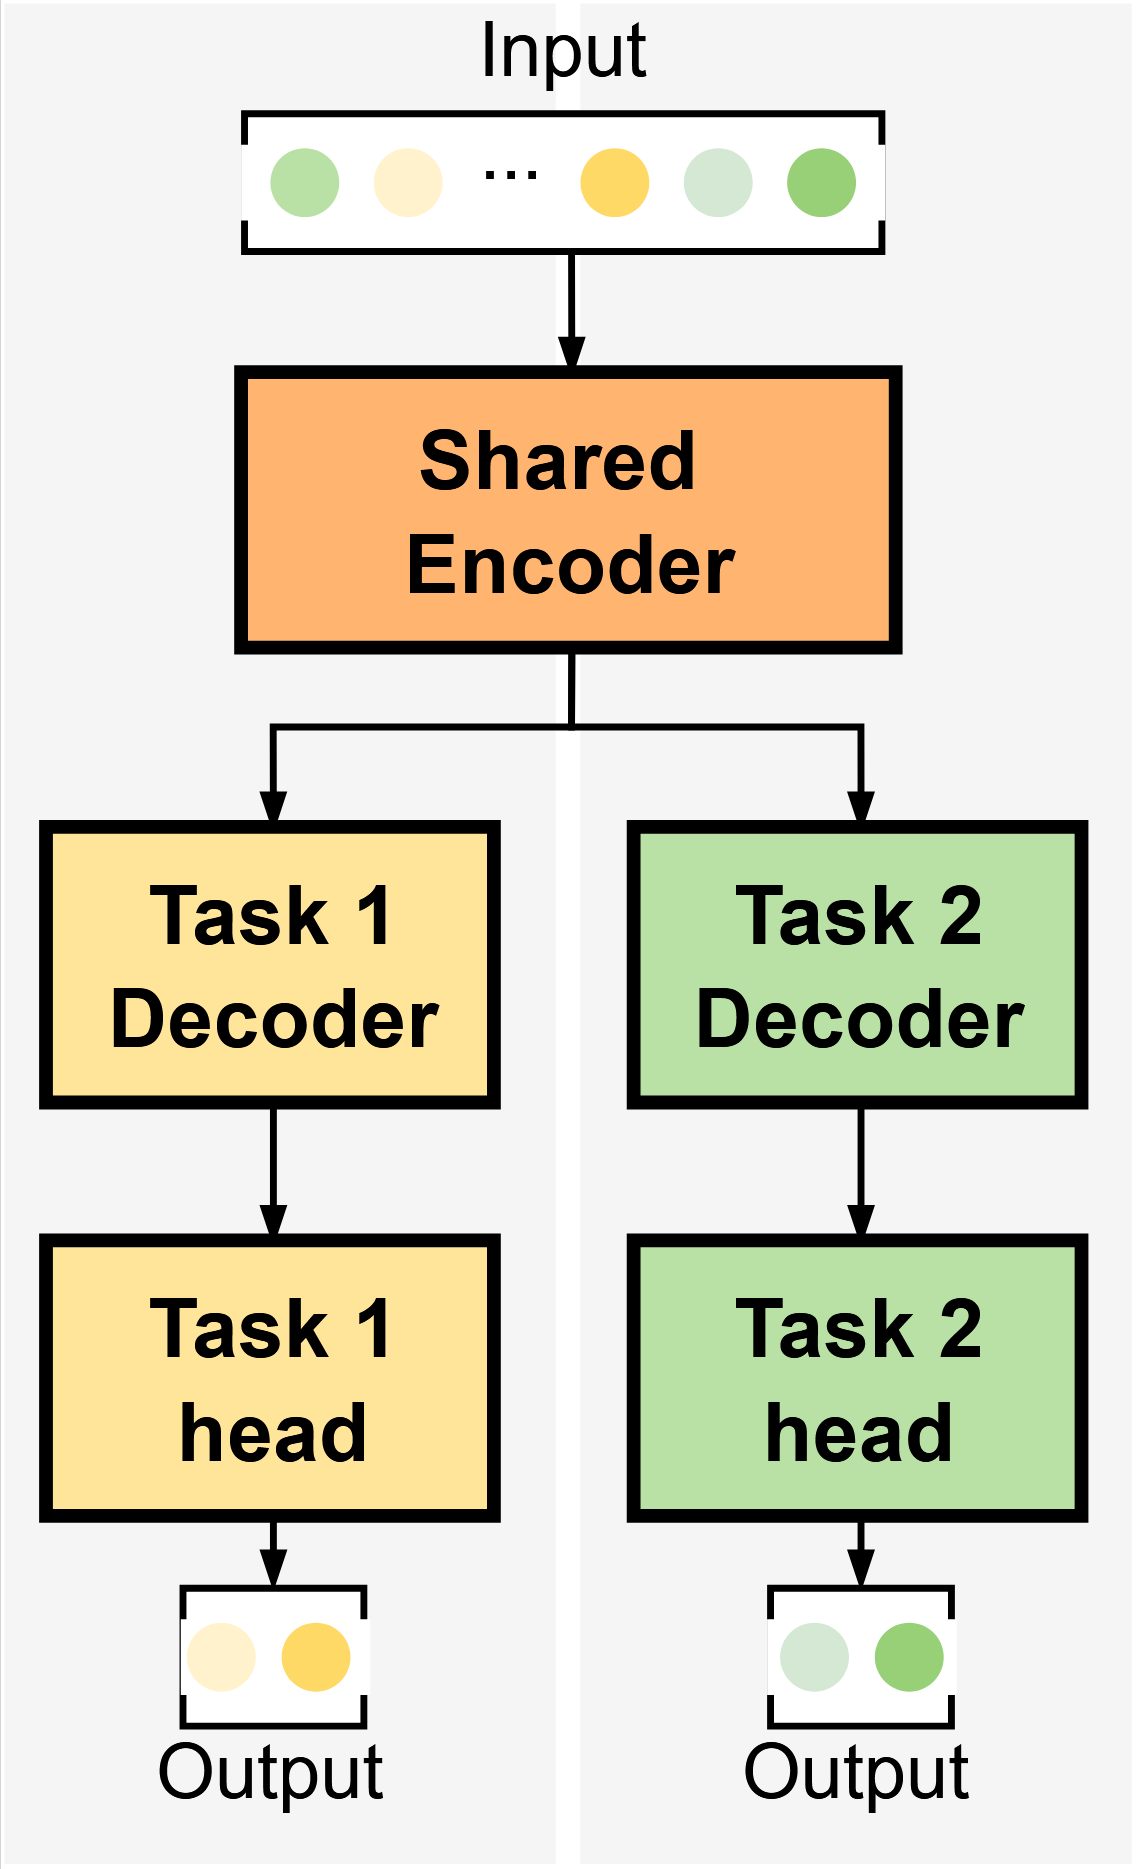

**Transfer/Continual Multitask Learning:** A full model is trained first for an auxiliary task, then the prediction head is discarded and the model is retrained/finetuned on the primary task. During this, the pretrained hidden layers are either frozen (only train the new prediction head) or trained again

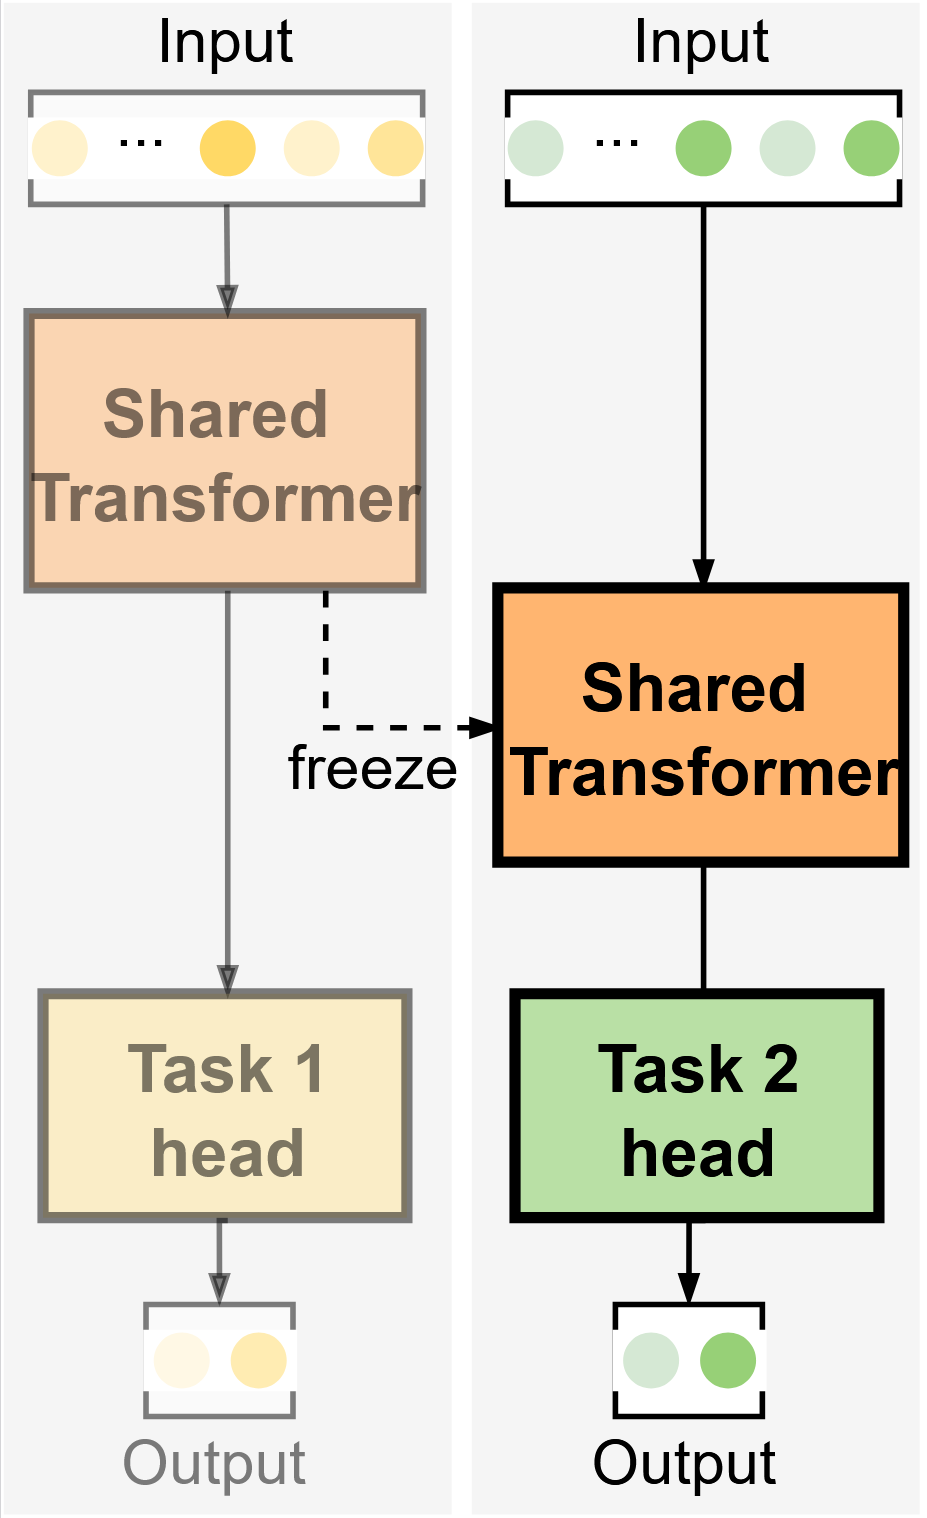

## Data

### Data Domains

The _Grammarly Argument Quality corpus_$^1$ comes from three different domains:

- **Online debates**  Two forums, _ConvinceMe_ (CM) and _ChangeMyView_ (CMV), where users share their stance on a topic and discuss their point of view, with replies aiming to change the view of the original poster
- **Q&A forum** Questions and corresponding 'best answers' from the most argumentative category of _Yahoo! Answers_ (YA; _Politics & Government $\to$ Law & Ethics_), with advice also included if sufficiently supported and argumentative
- **Reviews** _Yelp_ reviews, where the review text is considered as an argument defending the review rating (1$-$5 stars)

### Annotation Layers
The annotation follows the theory-based scheme of Wachsmuth et al. (2017)$^2$. All instances where judged on a 5-point scale by multiple experts and crowdworkers for each annotation layer. For this assignment, the mean of all annotations was converted into a binary judgment.

- **Overall argument quality**
- **Cogency** relates to the logical aspects of AQ, e.g., premises that are acceptable or relevant for the conclusion.
- **Effectiveness** indicates the rhetorical aspects of an argument, e.g., clarity or emotional appeal.
- **Reasonableness** reflects the AQ in the overall context of the discussion, e.g., relevance towards arriving at a resolution of the issue.

### Data Structure
The dataset is provided as a CSV file in `./data/GAQCorpus.csv` and includes:

- `text`: the main argument instance to classify
- `title`: the argument title, which varies depending on the domain (review score and subject for *reviews*, discussion title for *debates*, and the question for *Q&A*)
- `overall`: overall argument quality (0 or 1)
- `cogency`: the cogency of the argument (0 or 1)
- `effectiveness`: the effectiveness of the argument (0 or 1)
- `reasonableness`: the reasonableness of the argument (0 or 1)
- `split`: the data split the example belongs to (_train, validation, test_)
- `domain`: the source data (debate, review, q\&a), where this instance comes from

## Task Overview
### Model Selection

DeBERTa is a model employing an encoder-only transformer architecture, namely "**D**ecoding-**e**nhanced **B**idirectional **E**ncoder **R**epresentations from **T**ransformers with disentangled **a**ttention

- **Disentangled attention mechanism** Tokens are encoded as a content ($c$) and a position ($p$) vector, and the attention weights between tokens are computed separately ($c2c$, $p2p$, $c2p$, $p2c$) instead of all together.
  - $\to$ more effective modeling of long-range dependencies and word order

- **Enhanced mask decoder** BERT adds _absolute_ token positions to the transformer input, DeBERTa uses _relative_ positions and only adds _absolute_ positions to the transformer output. 
  - $\to$ better structural representation learning during pretraining

All experiments should be based on the [Huggingface  checkpoint](https://huggingface.co/microsoft/deberta-v3-base) of _DeBERTa v3_ $^{3,4}$

### Training Notes

In 3 of 4 tasks, you will need to finetune a DeBERTa model with [Huggingface](https://huggingface.co/docs/transformers/index) `Trainer`. For all tasks, observe the following requirements:

- All experiments should be based on `"microsoft/deberta-v3-base"` that is loaded to the assignment under `model_path`
- Use the _train_ split for finetuning and validate the training progress on the _dev_ split (see next point)
- Log the training procedure by reporting the training and validation loss and F$_1$ in sensible intervals (steps or epochs)
- The smaller dataset allows for longer training: experiment with 1-10 epochs and find (and note) the best range between overfitting and generalization (not necessary for every task)
- While training, do not save the model at each step/epoch, but rather think critically about which model you might want to load again
- The annotations are binary labels, thus you should choose a suitable model for classification.
- For all evaluations (during training and testing) you can use  [`scikit-learn`'s methods](https://scikit-learn.org/stable/api/sklearn.metrics.html#classification-metrics) and `matplotlib` or `seaborn` for any visualizations

In [ ]:
model_path = '/bigwork/nhwpquec/argumentation-technology-26s/deberta-v3-base/'
data_path = './data/GAQCorpus.csv'

---
## 1 $-$ Model Training
<div style="text-align: right"><b>10 points</b></div>

In this task, you will train several models for predicting argument quality and save their predictions for later analysis. the pretrained model from `model_path`. You will train a base model for each AQ dimension and for overall AQ, and use continual multitask learning to transfer the learned knowledge from the dimensions to the overall AQ task. Use the Huggingface library's [Trainer](https://huggingface.co/docs/transformers/v4.52.3/en/main_classes/trainer#trainer) and [TrainingArguments](https://huggingface.co/docs/transformers/v4.52.3/en/main_classes/trainer#transformers.TrainingArguments) for fine-tuning.

### 1.1 $-$ Wrapper Function

<div style="text-align: right"><b>8 points</b></div>

To avoid code duplication, first implement a reusable training function `train_aq_model()` that can be used for fine-tuning either the full model or only the classification head. 

- The function should accept the following arguments (**1 point**):
  - `training_data`: a dataframe as obtained by loading the data from the `data_path`.
  - `target_column`: a string indicating which dataframe column contains the gold labels for training (either _"cogency", "effectiveness", "reasonableness",_ or _"overall"_).
  - `model_path`: a string indicating the path to the base model used for training. The default model path should be the `model_path` variable given above.
  - `freeze_encoder`: a boolean indicating whether to freeze the encoder weights and train only the classification head (continual multitask setup) or not. The variable should default to `False`.

- Inside the function, use the given model path to load a suitable model for binary classification with the `transformers` library (**1 point**).
- For training, use the _training_ and _validation_ subset of the data as indicated in the `split` column and transform the data into the correct `transformers` input format (debate on the inclusion of `title` or only `text` and justify your decision).
- The function should then use the `Trainer` class to fine-tune the model on the training data. Here, you must distinguish between training the full model or only the classification head (**2 points**).
- Track the validation $F_1$ score during training and use the `eval_strategy` and `save_strategy` training arguments to save the best training checkpoint to `./outputs/` based on this metric (**2 points**).

    **Note:** It is important that you actually save only the best model even during training, as you might otherwise fill up your home directory quota with unnecessary intermediate checkpoints.
- The saved checkpoint path is dependent on the `target_column` and (if `freeze_encoder=True`) `model_path`: your checkpoint should be called `<dimension>_full` or `<base-mode-dimension>_overall_transfer`, e.g., `overall_full`, `cogency_full`, `cogency_overall_transfer` (**1 point**).
- After training, use the remaining _test_ data split to generate model predictions for the given target label and return them (**1 point**).


In [ ]:

import os
import shutil
from pathlib import Path
import inspect

import numpy as np
import pandas as pd
import torch
import transformers
from sklearn.metrics import f1_score
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ArgumentQualityDataset(Dataset):
    """Torch dataset wrapper around tokenized argument inputs and binary labels."""

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.astype(int).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(value[idx]) for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def _training_arguments(**kwargs):
    """Create TrainingArguments while supporting both old and new transformers names."""
    signature = inspect.signature(TrainingArguments.__init__)
    if "eval_strategy" not in signature.parameters and "eval_strategy" in kwargs:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
    return TrainingArguments(**kwargs)


def _checkpoint_name(target_column: str, model_path: str, freeze_encoder: bool) -> str:
    if not freeze_encoder:
        return f"{target_column}_full"

    base_name = Path(str(model_path).rstrip("/\\")).name
    if base_name.endswith("_full"):
        base_name = base_name[:-5]
    return f"{base_name}_{target_column}_transfer"


def train_aq_model(
    training_data: pd.DataFrame,
    target_column: str,
    model_path: str = model_path,
    freeze_encoder: bool = False,
):
    """
    Fine-tune a DeBERTa sequence classifier for one argument-quality label.

    The model receives title and text as a sentence pair. The title is kept because it
    often states the claim, question, topic, or review score that determines whether
    the argument is relevant and therefore can affect all AQ dimensions.

    Parameters
    ----------
    training_data : pandas.DataFrame
        Dataframe containing train, validation, and test splits.
    target_column : str
        Label column to train against: "cogency", "effectiveness", "reasonableness",
        or "overall".
    model_path : str, default=model_path
        Pretrained DeBERTa path or a previously fine-tuned checkpoint directory.
    freeze_encoder : bool, default=False
        If True, freeze the shared encoder and train only the classification head.
        This is used for the continual transfer setup.

    Returns
    -------
    pandas.Series
        Predicted binary labels for the test split, indexed like the test dataframe.
    """
    valid_targets = {"cogency", "effectiveness", "reasonableness", "overall"}
    if target_column not in valid_targets:
        raise ValueError(f"target_column must be one of {sorted(valid_targets)}")

    split_data = training_data.copy()
    split_data["split"] = split_data["split"].replace({"dev": "validation", "val": "validation"})
    train_df = split_data[split_data["split"] == "train"].reset_index(drop=True)
    val_df = split_data[split_data["split"] == "validation"].reset_index(drop=True)
    test_df = split_data[split_data["split"] == "test"].copy()

    if train_df.empty or val_df.empty or test_df.empty:
        raise ValueError("Expected non-empty train, validation, and test splits.")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)

    if freeze_encoder:
        for parameter in model.base_model.parameters():
            parameter.requires_grad = False

    def tokenize(df):
        titles = df["title"].fillna("").astype(str).tolist()
        texts = df["text"].fillna("").astype(str).tolist()
        return tokenizer(titles, texts, truncation=True, max_length=512)

    train_dataset = ArgumentQualityDataset(tokenize(train_df), train_df[target_column])
    val_dataset = ArgumentQualityDataset(tokenize(val_df), val_df[target_column])
    test_dataset = ArgumentQualityDataset(tokenize(test_df), test_df[target_column])
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    output_dir = Path("./outputs") / _checkpoint_name(target_column, model_path, freeze_encoder)
    output_dir.mkdir(parents=True, exist_ok=True)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return {"f1": f1_score(labels, predictions)}

    training_args = _training_arguments(
        output_dir=str(output_dir),
        num_train_epochs=3,
        learning_rate=2e-5 if not freeze_encoder else 5e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=50,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=42,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    trainer.save_model(str(output_dir))
    tokenizer.save_pretrained(str(output_dir))

    # Keep the reusable best-model directory compact instead of retaining epoch checkpoints.
    for checkpoint in output_dir.glob("checkpoint-*"):
        if checkpoint.is_dir():
            shutil.rmtree(checkpoint)

    logits = trainer.predict(test_dataset).predictions
    predictions = np.argmax(logits, axis=-1)
    return pd.Series(predictions, index=test_df.index, name=f"pred_{target_column}")


### 1.2 $-$ Training Execution
<div style="text-align: right"><b>2 points</b></div>

You should now use your wrapper function to train seven different models. Of these training calls, four setups fine-tune the DeBERTa base model fully for each target label (cogency, effectiveness, reasonableness, overall; **1 point**). 
The remaining three function calls should set `freeze_encoder=True` to fine-tune only the classification head after loading the three AQ dimension models from above (**1 point**). 

Create a dataframe copy of only the test data split, remove all columns but the gold label columns, and append each model's predictions. Save the resulting evaluation dataset with columns named as follows:

| Target Dimension | Base Model | Dataset Column |
| :--- | :--- | :--- |
| Overall AQ | DeBERTa | `pred_overall` |
| Cogency | DeBERTa | `pred_cogency` |
| Effectiveness | DeBERTa | `pred_effectiveness`|
| Reasonableness | DeBERTa | `pred_reasonableness`|
| Overall AQ | Cogency | `pred_overall_cogency` |
| Overall AQ | Effectiveness | `pred_overall_effectiveness` |
| Overall AQ | Reasonableness | `pred_overall_reasonableness` |

In [ ]:

from pathlib import Path

training_data = pd.read_csv(data_path)
training_data["split"] = training_data["split"].replace({"dev": "validation", "val": "validation"})

outputs_dir = Path("./outputs")
outputs_dir.mkdir(exist_ok=True)

test_predictions = training_data.loc[
    training_data["split"] == "test",
    ["overall", "cogency", "effectiveness", "reasonableness"],
].copy()

# Full fine-tuning from DeBERTa for each target label.
test_predictions["pred_overall"] = train_aq_model(training_data, "overall", model_path=model_path)
test_predictions["pred_cogency"] = train_aq_model(training_data, "cogency", model_path=model_path)
test_predictions["pred_effectiveness"] = train_aq_model(training_data, "effectiveness", model_path=model_path)
test_predictions["pred_reasonableness"] = train_aq_model(training_data, "reasonableness", model_path=model_path)

# Continual transfer: load each dimension model, freeze its encoder, and train the head for Overall AQ.
test_predictions["pred_overall_cogency"] = train_aq_model(
    training_data,
    "overall",
    model_path=str(outputs_dir / "cogency_full"),
    freeze_encoder=True,
)
test_predictions["pred_overall_effectiveness"] = train_aq_model(
    training_data,
    "overall",
    model_path=str(outputs_dir / "effectiveness_full"),
    freeze_encoder=True,
)
test_predictions["pred_overall_reasonableness"] = train_aq_model(
    training_data,
    "overall",
    model_path=str(outputs_dir / "reasonableness_full"),
    freeze_encoder=True,
)

evaluation_path = outputs_dir / "aq_test_predictions.csv"
test_predictions.to_csv(evaluation_path, index=False)
test_predictions.head()


## 2 $-$ Model Evaluation
<div style="text-align: right"><b>10 points</b></div>

Using the gold labels and saved predictions from Task 1, analyze the relationships between the argument quality dimensions and Overall AQ.

### 2.1 $-$ Label Relationships and Model Performance
<div style="text-align: right"><b>6 points</b></div>

Calculate the Pearson correlation between the gold labels of each AQ dimension and overall AQ (**2 points**). For all seven models, calculate the $F_1$ score using your saved predictions and the corresponding gold labels (**2 points**). Add all values to a table as shown below. Some columns will not apply to all dimensions (i.e., the Pearson coefficient or Transfer $F_1$ for the Overall AQ model). The table should be Markdown-formatted, values should be rounded to 3 decimal places, and the highest value in the transfer column should be highlighted in bold (**2 points**).


| AQ Dimension | Corr$_{AQ}$ | $F_1$ | Transfer $F_1$ |
| :--- | :--- | :--- | :--- |
| Overall AQ | | | |
| Cogency | | | |
| Effectiveness | | | |
| Reasonableness | | | |

In [ ]:

from IPython.display import Markdown, display
from sklearn.metrics import f1_score
from scipy.stats import pearsonr

try:
    test_predictions
except NameError:
    test_predictions = pd.read_csv("./outputs/aq_test_predictions.csv")

dimensions = ["overall", "cogency", "effectiveness", "reasonableness"]
full_prediction_cols = {
    "overall": "pred_overall",
    "cogency": "pred_cogency",
    "effectiveness": "pred_effectiveness",
    "reasonableness": "pred_reasonableness",
}
transfer_prediction_cols = {
    "cogency": "pred_overall_cogency",
    "effectiveness": "pred_overall_effectiveness",
    "reasonableness": "pred_overall_reasonableness",
}

def pearson_statistic(x, y):
    result = pearsonr(x, y)
    return result.statistic if hasattr(result, "statistic") else result[0]

corr_values = {
    dim: pearson_statistic(test_predictions[dim], test_predictions["overall"])
    for dim in ["cogency", "effectiveness", "reasonableness"]
}
f1_values = {
    dim: f1_score(test_predictions[dim], test_predictions[full_prediction_cols[dim]])
    for dim in dimensions
}
transfer_f1_values = {
    dim: f1_score(test_predictions["overall"], test_predictions[pred_col])
    for dim, pred_col in transfer_prediction_cols.items()
}
best_transfer_dimension = max(transfer_f1_values, key=transfer_f1_values.get)
best_transfer_f1 = transfer_f1_values[best_transfer_dimension]

rows = []
for dim in dimensions:
    transfer_value = ""
    if dim != "overall":
        transfer_value = f"{transfer_f1_values[dim]:.3f}"
        if dim == best_transfer_dimension:
            transfer_value = f"**{transfer_value}**"
    rows.append(
        {
            "AQ Dimension": "Overall AQ" if dim == "overall" else dim.capitalize(),
            "Corr$_{AQ}$": "" if dim == "overall" else f"{corr_values[dim]:.3f}",
            "$F_1$": f"{f1_values[dim]:.3f}",
            "Transfer $F_1$": transfer_value,
        }
    )

results_df = pd.DataFrame(rows)
display(Markdown(results_df.to_markdown(index=False)))


### 2.2 $-$ Transfer Comparison
<div style="text-align: right"><b>2 points</b></div>

Create a bar plot showing the $F_1$ scores of the three transfer models (Cogency $\to$ AQ, Effectiveness $\to$ AQ, Reasonableness $\to$ AQ). Include the $F_1$ score of the fully-trained AQ model as a vertical line. Add appropriate axis labels, a title, and a key to your figure.


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

transfer_plot_df = pd.DataFrame(
    {
        "Base Dimension": [dim.capitalize() for dim in transfer_f1_values],
        "F1": list(transfer_f1_values.values()),
    }
)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(data=transfer_plot_df, y="Base Dimension", x="F1", color="#4C78A8")
ax.axvline(f1_values["overall"], color="#D62728", linestyle="--", label=f"Overall full ({f1_values['overall']:.3f})")
ax.set_xlim(0, 1)
ax.set_xlabel("F1 score on Overall AQ")
ax.set_ylabel("Transfer source dimension")
ax.set_title("Transfer Models Compared with Direct Overall-AQ Fine-Tuning")
ax.legend(title="Reference")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()


### 2.3 $-$ Error Analyis
<div style="text-align: right"><b>2 points</b></div>

Given your values from 2.1, determine the best transfer model. Compare this model to the directly trained AQ model by creating confusion matrices for both. Because the dataset is not perfectly balanced, normalize the confusion matrices by the number of gold instances rather than displaying absolute counts. Display the two confusion matrices side-by-side using aligned subfigures.
 

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_transfer_col = transfer_prediction_cols[best_transfer_dimension]
comparison_models = {
    f"Overall full (F1={f1_values['overall']:.3f})": test_predictions["pred_overall"],
    f"{best_transfer_dimension.capitalize()} transfer (F1={best_transfer_f1:.3f})": test_predictions[best_transfer_col],
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, (title, predictions) in zip(axes, comparison_models.items()):
    matrix = confusion_matrix(test_predictions["overall"], predictions, labels=[0, 1], normalize="true")
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Gold 0", "Gold 1"],
        cbar=ax is axes[-1],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Gold label")

fig.suptitle("Normalized Confusion Matrices for Overall AQ")
plt.tight_layout()
plt.show()


---
## 3 $-$ Transfer Learning Analysis
<div style="text-align: right"><b>10 points</b></div>

With both label statistics and model performance results, we can now analyze how different argument quality dimensions relate to overall argument quality. For both subtasks below, structure your answer as follows:

1. **Claim** $-$ Verbalize and summarize the overall findings (**2 points**).
2. **Evidence** $-$ Include specific numbers from task 2. Include your generated tables and figures where necessary (**1 point**).
3. **Interpretation** $-$ Reason about why this observation might be happening and what it may mean about argument quality (**2 points**).

### 3.1 $-$ AQ Dimensions and Overall Quality
<div style="text-align: right"><b>5 points</b></div>

Analyze the relationship between the label correlations (2.1), the performance of the dimension-specific models (2.1), and the transfer results (2.2). Discuss how strongly the individual AQ dimensions appear to be related to Overall AQ and whether the transfer results follow the same pattern as the observed label correlations.

In [ ]:

from IPython.display import Markdown, display

corr_ranking = sorted(corr_values.items(), key=lambda item: item[1], reverse=True)
transfer_ranking = sorted(transfer_f1_values.items(), key=lambda item: item[1], reverse=True)

analysis_31 = f"""
**Claim.** The AQ dimensions are all positively related to Overall AQ, but the relationship is not equally strong. In this run, **{corr_ranking[0][0]}** has the strongest label-level association with Overall AQ, while **{best_transfer_dimension}** gives the strongest transfer model. This means the transfer results {'follow' if corr_ranking[0][0] == best_transfer_dimension else 'do not perfectly follow'} the simple label-correlation pattern.

**Evidence.** The Pearson correlations with Overall AQ are: cogency = {corr_values['cogency']:.3f}, effectiveness = {corr_values['effectiveness']:.3f}, and reasonableness = {corr_values['reasonableness']:.3f}. The directly trained models reach F1 scores of {f1_values['overall']:.3f} for Overall AQ, {f1_values['cogency']:.3f} for cogency, {f1_values['effectiveness']:.3f} for effectiveness, and {f1_values['reasonableness']:.3f} for reasonableness. For transfer to Overall AQ, the F1 scores are: cogency -> AQ = {transfer_f1_values['cogency']:.3f}, effectiveness -> AQ = {transfer_f1_values['effectiveness']:.3f}, and reasonableness -> AQ = {transfer_f1_values['reasonableness']:.3f}. The strongest transfer result is therefore {best_transfer_dimension} -> AQ with F1 = {best_transfer_f1:.3f}.

**Interpretation.** A high label correlation suggests that a dimension overlaps conceptually with Overall AQ, but transfer performance also depends on what the source training teaches the encoder to represent. A dimension can correlate strongly with Overall AQ and still transfer less well if its learned decision boundary is narrower, noisier, or less compatible with the final Overall-AQ labels. Conversely, a dimension with slightly weaker raw correlation may transfer better if it encourages broadly useful representations of argument context, clarity, relevance, and support. Overall AQ therefore seems to combine several signals rather than being reducible to one single quality dimension.
"""

display(Markdown(analysis_31))


### 3.2 $-$ Transfer Learning and Error Behavior
<div style="text-align: right"><b>5 points</b></div>

Analyze the best transfer model and compare it to the directly trained AQ model. Use the evaluation results, the transfer comparison plot, and the confusion matrices. Discuss what the results suggest about the usefulness of transfer learning for AQ prediction and how the two models differ in their prediction behavior.


In [ ]:

from IPython.display import Markdown, display

transfer_delta = best_transfer_f1 - f1_values["overall"]
comparison_phrase = "outperforms" if transfer_delta > 0 else "underperforms compared with"

analysis_32 = f"""
**Claim.** The best transfer model is the **{best_transfer_dimension} -> Overall AQ** model. It {comparison_phrase} the directly trained Overall-AQ model by {abs(transfer_delta):.3f} F1, so transfer learning is {'beneficial in this setup' if transfer_delta > 0 else 'not better than direct fine-tuning in this setup'}.

**Evidence.** The direct Overall-AQ model reaches F1 = {f1_values['overall']:.3f}. The best transfer model, initialized from the {best_transfer_dimension} model and then trained with a frozen encoder for Overall AQ, reaches F1 = {best_transfer_f1:.3f}. The bar plot in 2.2 shows this transfer score relative to the direct Overall-AQ baseline, and the normalized confusion matrices in 2.3 show how often each model predicts class 0 or class 1 within each gold class.

**Interpretation.** If the transfer model has stronger diagonal values in the normalized confusion matrix, it has learned a representation that separates low- and high-quality arguments more reliably despite seeing Overall-AQ supervision only in the classification head. If the direct Overall-AQ model has the stronger diagonal, full fine-tuning on the target label is more useful than reusing a frozen dimension-specific encoder. Differences between the off-diagonal cells reveal the models' prediction bias: a larger false-positive cell means the model is too willing to label arguments as high quality, while a larger false-negative cell means it is too conservative. This comparison is important because two models can have similar F1 scores while making different types of errors.
"""

display(Markdown(analysis_32))


---
## References

$^1$ Anne Lauscher, Lily Ng, Courtney Napoles, and Joel Tetreault. 2020. [Rhetoric, logic, and dialectic: Advancing theory-based argument quality assessment in natural language processing](https://doi.org/10.18653/v1/2020.coling-main.402). In _Proceedings of the 28th International Conference on Computational Linguistics_, pages 4563–4574..
International Committee on Computational Linguistics.

$^2$ Henning Wachsmuth, Nona Naderi, Yufang Hou, Yonatan Bilu, Vinodkumar Prabhakaran, Tim Alberdingk Thijm, Graeme Hirst, and Benno Stein. 2017. [Computational argumentation quality assessment in natural language](https://aclanthology.org/E17-1017/). In _Proceedings of the 15th Conference of the European Chapter of the Association for Computational Linguistics: Volume 1, Long Papers_, pages 176–187.

$^3$ Pengcheng He, Xiaodong Liu, Jianfeng Gao, and Weizhu Chen. 2021. [DeBERTa: Decoding-enhanced bert with disentangled attention](https://arxiv.org/abs/2006.03654). _Preprint_, arXiv:2006.03654.

$^4$ Pengcheng He, Jianfeng Gao, and Weizhu Chen. 2023. [DeBERTa v3: Improving deberta using electra-style pre-training with gradient-disentangled embedding sharing](https://arxiv.org/abs/2111.09543). _Preprint_, arXiv:2111.09543.